In [1]:
import mysql.connector
import os
from matplotlib import pyplot as plt
import numpy as np

In [2]:
import mysql.connector
mydb = mysql.connector.connect(
    host = "localhost",
    user = os.getenv("MYSQL_USER"),
    password = os.getenv("MYSQL_PASSWORD"),
    database = 'wingspan'
)
print(mydb)

In [3]:
mycursor = mydb.cursor()

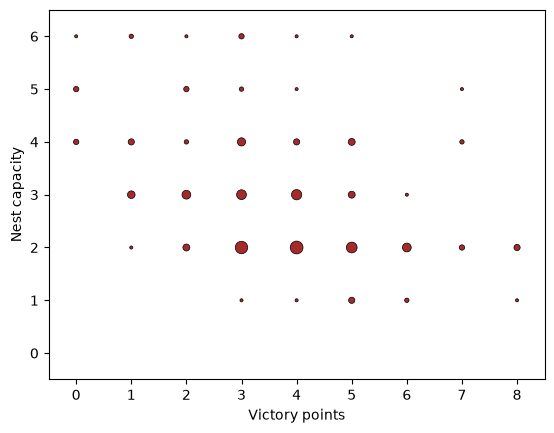

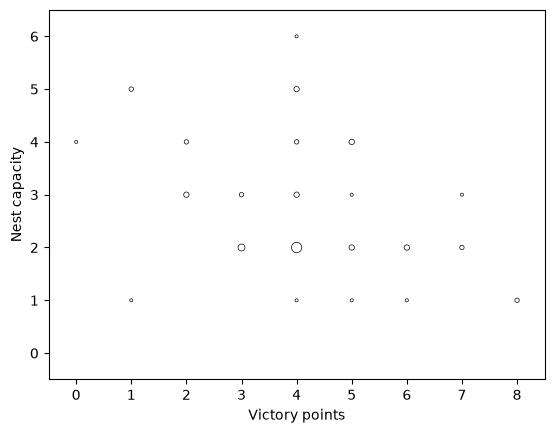

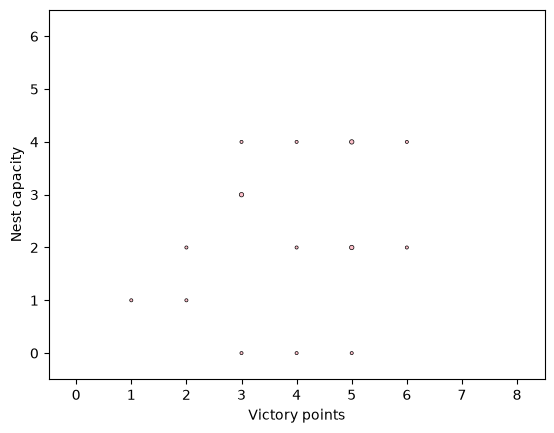

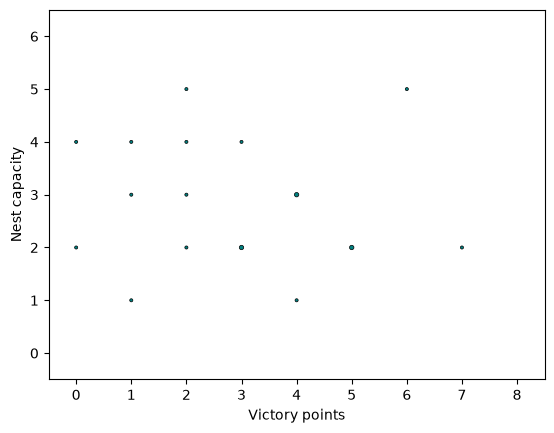

In [4]:
#Plot nest capacity/victory points distribution per bird power color
for color, cmarker in zip(('BR', 'WH', 'PK', 'TL'), ('brown', 'white', 'pink', 'teal')):
    mycursor.execute("SELECT b.victory_points, b.nest_capacity \
                      FROM bird b INNER JOIN power p \
                      ON b.power_id = p.power_id \
                      WHERE p.color = '{}'".format(color))
    data, count = np.unique([row for row in mycursor.fetchall()], axis = 0, return_counts = True)

    plt.figure()
    plt.scatter(data[:, 0], data[:, 1], s = 5*count, linewidths=0.5, edgecolors='black', c = cmarker)
    plt.xlabel("Victory points")
    plt.ylabel("Nest capacity")
    plt.axis(xmin=-0.5, ymin=-0.5, ymax=6.5, xmax=8.5);

Text(0, 0.5, 'Victory points')

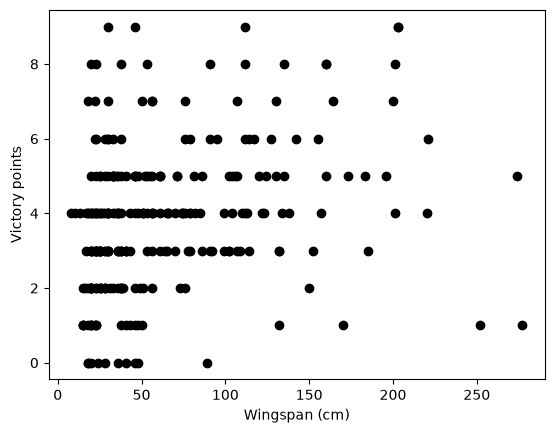

In [14]:
#Inspect how victory points are distributed as a function of wingspan
mycursor.execute("SELECT wingspan, victory_points FROM bird");

data = np.array([row for row in mycursor.fetchall()])

plt.figure()
plt.scatter(data[:, 0], data[:, 1], c = 'black')
plt.xlabel("Wingspan (cm)")
plt.ylabel("Victory points")



Text(0, 0.5, 'Nest capacity')

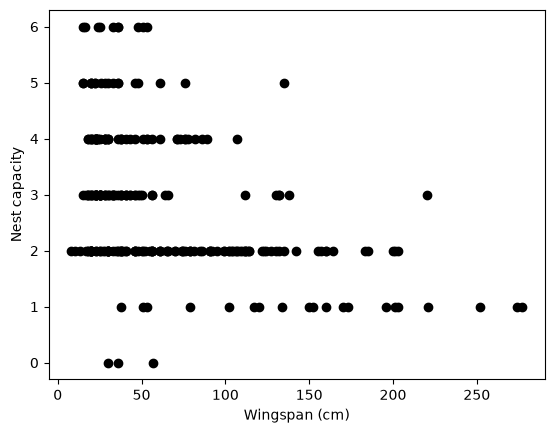

In [15]:
#Inspect how nest capacities are distributed as a function of wingspan
mycursor.execute("SELECT wingspan, nest_capacity FROM bird");

data = np.array([row for row in mycursor.fetchall()])

plt.figure()
plt.scatter(data[:, 0], data[:, 1], c = 'black')
plt.xlabel("Wingspan (cm)")
plt.ylabel("Nest capacity")
